In [ ]:
import yfinance as yf
import pandas as pd

# Indian stock symbol
symbol = "HDFCBANK.NS"

# Fetch past 3 years daily data
data_3y = yf.download(
    tickers=symbol,
    period="3y",      # 👈 Past 3 years
    interval="1d",    # 👈 Daily data
    auto_adjust=False,
    progress=False
)

# Clean column names (remove multi-index if any)
data_3y.columns = data_3y.columns.get_level_values(0)

# Reset index to make Date a column
data_3y.reset_index(inplace=True)

# Convert Date to datetime
data_3y['Date'] = pd.to_datetime(data_3y['Date'])

# Display last 5 rows
print("Last 5 days of historical data:")
print(data_3y.tail())

# Save to CSV
data_3y.to_csv("hdfc_3Y_Historical.csv", index=False)

print("\n✅ Past 3 years RELIANCE data saved as hdfc_3Y_Historical.csv")


Last 5 days of historical data:
Price       Date   Adj Close       Close        High         Low        Open  \
737   2025-12-16  994.299988  994.299988  998.700012  990.099976  990.099976   
738   2025-12-17  984.000000  984.000000  996.000000  980.799988  996.000000   
739   2025-12-18  979.700012  979.700012  987.400024  973.299988  973.299988   
740   2025-12-19  985.500000  985.500000  988.000000  978.700012  987.000000   
741   2025-12-22  987.700012  987.700012  992.900024  983.900024  988.000000   

Price    Volume  
737    20049088  
738    19080922  
739    14912404  
740    25952384  
741    13539396  

✅ Past 3 years RELIANCE data saved as hdfc_3Y_Historical.csv


In [ ]:
df = pd.read_csv("hdfc_3Y_Historical.csv")
df['Date'] = pd.to_datetime(df['Date'])

print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       742 non-null    datetime64[ns]
 1   Adj Close  742 non-null    float64       
 2   Close      742 non-null    float64       
 3   High       742 non-null    float64       
 4   Low        742 non-null    float64       
 5   Open       742 non-null    float64       
 6   Volume     742 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 40.7 KB
None
        Date   Adj Close       Close        High         Low        Open  \
0 2022-12-22  775.666443  806.025024  813.750000  804.500000  811.099976   
1 2022-12-23  768.737732  798.825012  802.075012  792.724976  793.500000   
2 2022-12-26  784.038757  814.724976  819.500000  795.000000  799.750000   
3 2022-12-27  784.832703  815.549988  817.974976  806.750000  816.500000   
4 2022-12-28  784.

In [ ]:
# Volatility
df['hl_range'] = df['High'] - df['Low']

# Momentum
df['oc_change'] = df['Close'] - df['Open']

# Percentage change
df['pct_change'] = df['Close'].pct_change() * 100

# Moving Averages
df['ma_5'] = df['Close'].rolling(5).mean()
df['ma_10'] = df['Close'].rolling(10).mean()
df['ma_20'] = df['Close'].rolling(20).mean()


In [ ]:
pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=f19c55ad899d0c5f9f7a09d65db24ffbd76e8d31841ce1b2a81f29e1a366fcec
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import ta

# RSI
df['rsi'] = ta.momentum.RSIIndicator(
    close=df['Close'], window=14
).rsi()

# MACD
macd = ta.trend.MACD(df['Close'])
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()
df['macd_diff'] = macd.macd_diff()

# ADX
df['adx'] = ta.trend.ADXIndicator(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    window=14
).adx()

# Bollinger Bands width
bb = ta.volatility.BollingerBands(df['Close'])
df['bb_width'] = bb.bollinger_wband()

# Drop NaNs from indicators
df.dropna(inplace=True)

print("Rows after TA features:", len(df))


Rows after TA features: 709


In [ ]:
def trend_strength(row):

    # STRONG BUY
    if (
        row['Close'] > row['ma_20'] and
        row['ma_5'] > row['ma_10'] > row['ma_20'] and
        row['rsi'] > 60 and
        row['adx'] > 25 and
        row['macd_diff'] > 0
    ):
        return 3

    # BUY
    elif (
        row['Close'] > row['ma_10'] and
        row['rsi'] > 55 and
        row['macd_diff'] > 0
    ):
        return 2

    # HOLD (refined, realistic)
    elif (
        45 <= row['rsi'] <= 55 and
        row['adx'] < 20 and
        abs(row['macd_diff']) < 0.02
    ):
        return 1

    # SELL
    else:
        return 0


In [ ]:
df['trend_class'] = df.apply(trend_strength, axis=1)

print("Label distribution:")
print(df['trend_class'].value_counts().sort_index())


Label distribution:
trend_class
0    481
2    165
3     63
Name: count, dtype: int64


In [ ]:
features = [
    'Close', 'hl_range', 'oc_change', 'pct_change',
    'ma_5', 'ma_10', 'ma_20',
    'rsi', 'adx',
    'macd', 'macd_signal', 'macd_diff',
    'bb_width'
]

X = df[features]
y = df['trend_class']


In [ ]:
# Map existing labels to 0-based continuous labels
label_mapping = {
    1: 0,  # Sell
    2: 1,  # Hold
    3: 2,  # Buy
    4: 3   # Strong Buy
}

df['trend_class_mapped'] = df['trend_class'].map(label_mapping)

print("Mapped class distribution:")
print(df['trend_class_mapped'].value_counts().sort_index())


Mapped class distribution:
trend_class_mapped
1.0    165
2.0     63
Name: count, dtype: int64


In [ ]:
df['trend_class'] = df.apply(trend_strength, axis=1)


In [ ]:
# Get unique classes actually present
unique_classes = sorted(df['trend_class'].unique())
print("Original classes:", unique_classes)

# Create automatic mapping (safe)
label_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}

df['trend_class_mapped'] = df['trend_class'].map(label_mapping)

print("Mapped classes:")
print(df['trend_class_mapped'].value_counts().sort_index())


Original classes: [np.int64(0), np.int64(2), np.int64(3)]
Mapped classes:
trend_class_mapped
0    481
1    165
2     63
Name: count, dtype: int64


In [ ]:
X = df[features]
y = df['trend_class_mapped']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    objective="multi:softprob",  # 🔥 CHANGE HERE
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model trained with probability output")


✅ Model trained with probability output


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



🎯 Accuracy: 97.18%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        82
           1       0.98      0.93      0.95        45
           2       0.94      1.00      0.97        15

    accuracy                           0.97       142
   macro avg       0.96      0.97      0.97       142
weighted avg       0.97      0.97      0.97       142



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:
# Predict classes
y_pred = model.predict(X_test)


In [ ]:
cm = confusion_matrix(y_test, y_pred)


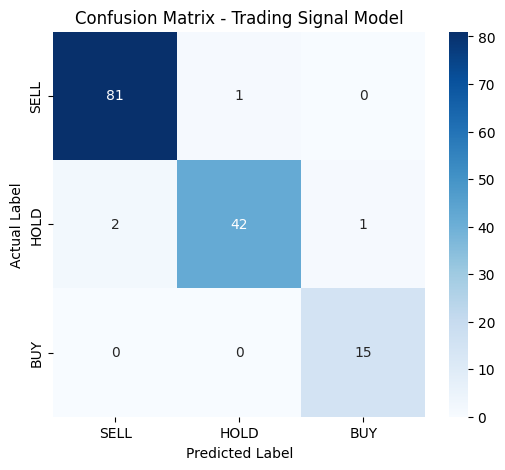

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["SELL", "HOLD", "BUY"],
    yticklabels=["SELL", "HOLD", "BUY"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Trading Signal Model")
plt.show()


In [ ]:
import numpy as np

def final_signal(cls):
    if cls in [3, 2]:
        return "BUY"
    elif cls == 1:
        return "HOLD"
    else:
        return "SELL"

# 1️⃣ Get prediction probabilities
proba = model.predict_proba(X)

# 2️⃣ Predicted class
df['trend_class_pred'] = np.argmax(proba, axis=1)

# 3️⃣ Confidence (0–1)
df['confidence'] = np.max(proba, axis=1)

# 4️⃣ Confidence in percentage
df['confidence_pct_value'] = (df['confidence'] * 100).round(2)
df['confidence_pct'] = df['confidence_pct_value'].astype(str) + '%'


# 5️⃣ Final signal
df['signal'] = df['trend_class_pred'].apply(final_signal)

# 6️⃣ Display result
df[['Date', 'Close', 'trend_class_pred', 'signal', 'confidence_pct']].tail(30)


,Date,Close,trend_class_pred,signal,confidence_pct
712,2025-11-11,991.700012,0,SELL,99.84%
713,2025-11-12,989.500000,0,SELL,99.86%
714,2025-11-13,986.650024,0,SELL,99.85%
715,2025-11-14,989.599976,0,SELL,99.87%
716,2025-11-17,996.549988,0,SELL,97.84%
717,2025-11-18,992.450012,0,SELL,99.79%
718,2025-11-19,994.599976,0,SELL,99.9%
719,2025-11-20,1008.849976,1,HOLD,99.7%
720,2025-11-21,998.049988,0,SELL,99.02%
721,2025-11-24,999.150024,1,HOLD,96.81%


In [ ]:
comparison = df[['trend_class', 'trend_class_pred']]
print((comparison['trend_class'] == comparison['trend_class_pred']).value_counts())


True     481
False    228
Name: count, dtype: int64


In [ ]:
def generate_technical_reason(row):
    reasons = []

    if row['macd_diff'] < 0:
        reasons.append("Bearish MACD momentum")
    elif row['macd_diff'] > 0:
        reasons.append("Bullish MACD momentum")

    if row['rsi'] > 70:
        reasons.append("RSI overbought")
    elif row['rsi'] < 30:
        reasons.append("RSI oversold")
    elif 45 <= row['rsi'] <= 55:
        reasons.append("RSI neutral")

    if row['adx'] < 20:
        reasons.append("Weak trend strength")
    elif row['adx'] > 25:
        reasons.append("Strong trend strength")

    if row['Close'] > row['ma_20']:
        reasons.append("Price above 20-day average")
    else:
        reasons.append("Price below 20-day average")

    return ", ".join(reasons)

df['technical_reason'] = df.apply(generate_technical_reason, axis=1)


In [ ]:
def generate_simple_reason(row, pred_class):
    messages = []

    if row['macd_diff'] < 0:
        messages.append("Selling pressure is stronger than buying pressure")
    elif row['macd_diff'] > 0:
        messages.append("Buying pressure is stronger than selling pressure")

    if row['adx'] < 20:
        messages.append("The market trend is weak and unclear")
    elif row['adx'] > 25:
        messages.append("The market trend is strong")

    if row['rsi'] > 70:
        messages.append("The price may be too high right now")
    elif row['rsi'] < 30:
        messages.append("The price may be undervalued")

    if pred_class == 0:
        messages.append("This is not a good time to buy")
    elif pred_class == 1:
        messages.append("Waiting is safer before taking action")
    else:
        messages.append("Conditions are favorable for buying")

    return ". ".join(messages) + "."


In [ ]:
df[
    [
        'Date',
        'Close',
        'signal',
        'confidence_pct',
        'simple_reason',
        'technical_reason'
    ]
].tail(10)


KeyError: "['simple_reason'] not in index"

In [ ]:
df = df.sort_values('Date').reset_index(drop=True)
import joblib
joblib.dump(model, "HDFCBANK.pkl")



['HDFCBANK.pkl']

In [ ]:
from google.colab import files

files.download("HDFCBANK.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = df.sort_values('Date').reset_index(drop=True)


In [ ]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]


In [ ]:
X_train_time = train_df[features]
y_train_time = train_df['trend_class_mapped']

X_test_time  = test_df[features]
y_test_time  = test_df['trend_class_mapped']


In [ ]:
from xgboost import XGBClassifier

time_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

time_model.fit(X_train_time, y_train_time)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

proba_time = time_model.predict_proba(X_test_time)
y_pred_time = np.argmax(proba_time, axis=1)

accuracy_time = accuracy_score(y_test_time, y_pred_time)

print(f"⏳ Time-based Accuracy: {accuracy_time * 100:.2f}%")
print("\nClassification Report (Time-based):")
print(classification_report(y_test_time, y_pred_time))


⏳ Time-based Accuracy: 97.20%

Classification Report (Time-based):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        98
           1       1.00      0.77      0.87        13
           2       0.91      1.00      0.96        32

    accuracy                           0.97       143
   macro avg       0.97      0.92      0.94       143
weighted avg       0.97      0.97      0.97       143



In [ ]:
def fetch_live_data():
    df_live = yf.download(
        tickers=symbol,
        period="2d",
        interval="5m",
        auto_adjust=False,
        progress=False
    )

    df_live.columns = df_live.columns.get_level_values(0)
    df_live.reset_index(inplace=True)

    # Convert to datetime with timezone
    df_live['Datetime'] = pd.to_datetime(df_live['Datetime'], utc=True)

    # Convert UTC → IST
    df_live['Datetime'] = df_live['Datetime'].dt.tz_convert('Asia/Kolkata')

    return df_live


In [ ]:
import ta

def prepare_features(df):
    df = df.copy()

    # Basic features
    df['hl_range'] = df['High'] - df['Low']
    df['oc_change'] = df['Close'] - df['Open']
    df['pct_change'] = df['Close'].pct_change() * 100

    # Moving averages
    df['ma_5'] = df['Close'].rolling(5).mean()
    df['ma_10'] = df['Close'].rolling(10).mean()
    df['ma_20'] = df['Close'].rolling(20).mean()

    # Technical indicators
    df['rsi'] = ta.momentum.RSIIndicator(df['Close']).rsi()

    macd = ta.trend.MACD(df['Close'])
    df['macd'] = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    df['macd_diff'] = macd.macd_diff()

    df['adx'] = ta.trend.ADXIndicator(
        df['High'], df['Low'], df['Close']
    ).adx()

    bb = ta.volatility.BollingerBands(df['Close'])
    df['bb_width'] = bb.bollinger_wband()

    df.dropna(inplace=True)
    return df


In [ ]:
import numpy as np

def predict_live_signal(model):
    df_live = fetch_live_data()
    df_feat = prepare_features(df_live)

    # Take the latest candle only
    latest = df_feat.iloc[-1:]

    # Model input
    X_live = latest[features]

    # Predict probabilities
    proba = model.predict_proba(X_live)
    pred_class = np.argmax(proba, axis=1)[0]
    confidence = np.max(proba, axis=1)[0]

    # Signal
    signal = final_signal(pred_class)

    # Reasons
    technical_reason = generate_technical_reason(latest.iloc[0])
    simple_reason = generate_simple_reason(latest.iloc[0], pred_class)

    return {
        "Datetime": latest['Datetime'].values[0],
        "Price": latest['Close'].values[0],
        "Signal": signal,
        "Confidence": f"{confidence * 100:.2f}%",
        "Simple Reason": simple_reason,
        "Technical Reason": technical_reason
    }


In [ ]:
import os
import pandas as pd

LOG_FILE = "live_predictions_log.csv"

def log_result(result):
    df_log = pd.DataFrame([result])

    if not os.path.exists(LOG_FILE):
        df_log.to_csv(LOG_FILE, index=False)
    else:
        df_log.to_csv(LOG_FILE, mode='a', header=False, index=False)


In [ ]:
pip install mplfinance

In [ ]:
import matplotlib.pyplot as plt
import mplfinance as mpf


In [ ]:
import mplfinance as mpf
import matplotlib.pyplot as plt
import pandas as pd

def plot_live_chart(df, symbol, signal, timestamp):
    df_plot = df.copy()

    # Set Datetime as index
    df_plot.set_index('Datetime', inplace=True)

    # Keep last 30 candles
    df_plot = df_plot.tail(30)

    # Create filename
    time_str = pd.to_datetime(timestamp).strftime('%Y-%m-%d_%H-%M')
    file_path = f"{CHART_DIR}/{symbol}_{time_str}.png"

    # Chart style
    mc = mpf.make_marketcolors(up='green', down='red', inherit=True)
    style = mpf.make_mpf_style(marketcolors=mc)

    # Plot and save
    mpf.plot(
        df_plot,
        type='candle',
        style=style,
        title=f"{symbol} | 5-Min Chart | Signal: {signal}",
        ylabel='Price',
        volume=True,
        figsize=(10, 6),
        show_nontrading=False,
        savefig=file_path
    )

    return file_path


In [ ]:
import time
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

def run_live_auto_prediction(model, interval_minutes=5):
    print("🚀 Live auto-prediction started")
    print("⏹ Press CTRL+C to stop\n")

    while True:
        try:
            # 🔹 Predict live signal
            result = predict_live_signal(model)

            print("\n📊 LIVE MARKET SIGNAL")
            print("----------------------------")
            print(
                "Time       :",
                pd.to_datetime(result['Datetime']).strftime('%Y-%m-%d %H:%M:%S IST')
            )
            print(f"Price      : ₹{result['Price']:.2f}")
            print(f"Signal     : {result['Signal']}")
            print(f"Confidence : {result['Confidence']}")

            print("\nSimple Reason:")
            print(result['Simple Reason'])

            print("\nTechnical Reason:")
            print(result['Technical Reason'])

            # 🔹 Fetch live data again for chart
            df_live = fetch_live_data()

            # 🔹 Save and plot chart
            chart_path = plot_live_chart(
                df_live,
                symbol,
                result['Signal'],
                result['Datetime']
            )

            print(f"\n🖼 Chart saved at: {chart_path}")

            # 🔹 Log result (if logging enabled)
            log_result({
                "Datetime": result['Datetime'],
                "Price": result['Price'],
                "Signal": result['Signal'],
                "Confidence": result['Confidence'],
                "Simple Reason": result['Simple Reason'],
                "Technical Reason": result['Technical Reason'],
                "Chart Path": chart_path,
                "Logged At": datetime.now()
            })

            print(f"\n⏳ Waiting {interval_minutes} minutes for next update...\n")
            time.sleep(interval_minutes * 60)

        except KeyboardInterrupt:
            print("\n🛑 Auto-prediction stopped by user.")
            break

        except Exception as e:
            print(f"\n⚠️ Error occurred: {e}")
            print("Retrying in 60 seconds...")
            time.sleep(60)


In [ ]:
run_live_auto_prediction(model, interval_minutes=5)


🚀 Live auto-prediction started
⏹ Press CTRL+C to stop


⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Retrying in 60 seconds...

⚠️ Error occurred: 'Datetime'
Re

In [ ]:
import joblib

joblib.dump(features, "features.pkl")


['features.pkl']

In [ ]:
from google.colab import files

files.download("trend_model.pkl")
files.download("features.pkl")
files.download("live_predictions_log.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r charts.zip charts


  adding: charts/ (stored 0%)
  adding: charts/RELIANCE.NS_2025-12-19_09-55.png (deflated 18%)


In [ ]:
files.download("charts.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>